In [1]:
import pandas as pd #handle and organize data
import numpy as np #do math operations
import seaborn as sns #draw beautiful/statistical graphs
import matplotlib.pyplot as plt #draw basic graphs
import scipy.stats as stats #perform statistical analysis

In [2]:
dataset=pd.read_csv("Placement.csv")
dataset

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,NaN
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210,211,M,80.60,Others,82.00,Others,Commerce,77.60,Comm&Mgmt,No,91.0,Mkt&Fin,74.49,Placed,400000.0
211,212,M,58.00,Others,60.00,Others,Science,72.00,Sci&Tech,No,74.0,Mkt&Fin,53.62,Placed,275000.0
212,213,M,67.00,Others,67.00,Others,Commerce,73.00,Comm&Mgmt,Yes,59.0,Mkt&Fin,69.72,Placed,295000.0
213,214,F,74.00,Others,66.00,Others,Commerce,58.00,Comm&Mgmt,No,70.0,Mkt&HR,60.23,Placed,204000.0


In [3]:
dataset.isnull().sum()

sl_no              0
gender             0
ssc_p              0
ssc_b              0
hsc_p              0
hsc_b              0
hsc_s              0
degree_p           0
degree_t           0
workex             0
etest_p            0
specialisation     0
mba_p              0
status             0
salary            67
dtype: int64

In [4]:
dataset['salary'].fillna(0,inplace=True)

In [5]:
dataset.to_csv("preplacement.csv", index=False)

In [6]:
dataset.isnull().sum()

sl_no             0
gender            0
ssc_p             0
ssc_b             0
hsc_p             0
hsc_b             0
hsc_s             0
degree_p          0
degree_t          0
workex            0
etest_p           0
specialisation    0
mba_p             0
status            0
salary            0
dtype: int64

# How many of them are not placed?

In [7]:
not_placed_count=(dataset['status']=='Not Placed').sum()
print("The number of student who didnt got placed:",not_placed_count)

The number of student who didnt got placed: 67


# Find the reason for non placement from the dataset?

In [8]:
pd.crosstab(dataset['workex'], dataset['status'], normalize='index') * 100

status,Not Placed,Placed
workex,,
No,40.425532,59.574468
Yes,13.513514,86.486486


In [9]:
#1. Compare averages (for numeric columns)
not_placed = dataset[dataset['status'] == 'Not Placed']
placed = dataset[dataset['status'] == 'Placed']
print("Not Placed Mean:\n", not_placed.mean(numeric_only=True))
print("\nPlaced Mean:\n", placed.mean(numeric_only=True))

Not Placed Mean:
 sl_no       110.477612
ssc_p        57.544030
hsc_p        58.395522
degree_p     61.134179
etest_p      69.587910
mba_p        61.612836
salary        0.000000
dtype: float64

Placed Mean:
 sl_no          106.878378
ssc_p           71.721486
hsc_p           69.926554
degree_p        68.740541
etest_p         73.238041
mba_p           62.579392
salary      288655.405405
dtype: float64


In [10]:
#Check categorical impact using percentages
pd.crosstab(dataset['specialisation'], dataset['status'], normalize='index') * 100

status,Not Placed,Placed
specialisation,,
Mkt&Fin,20.833333,79.166667
Mkt&HR,44.210526,55.789474


In [11]:
pd.crosstab([dataset['workex'], dataset['specialisation']],dataset['status'],normalize='index') * 100

status                 Not Placed     Placed
workex specialisation                       
No     Mkt&Fin          30.434783  69.565217
       Mkt&HR           50.000000  50.000000
Yes    Mkt&Fin           7.843137  92.156863
       Mkt&HR           26.086957  73.913043

In [12]:
ct = pd.crosstab([dataset['workex'], dataset['specialisation']],dataset['status'],normalize='index') * 100
print(ct['Not Placed'],)

workex  specialisation
No      Mkt&Fin           30.434783
        Mkt&HR            50.000000
Yes     Mkt&Fin            7.843137
        Mkt&HR            26.086957
Name: Not Placed, dtype: float64


In [13]:
# . Analyze multiple columns quickly
columns = ['gender', 'ssc_b', 'hsc_b','workex', 'degree_t', 'specialisation']
for col in columns:
    print(f"\n--- {col} ---")
    print(pd.crosstab(dataset[col], dataset['status'], normalize='index') * 100)


--- gender ---
status  Not Placed     Placed
gender                       
F        36.842105  63.157895
M        28.057554  71.942446

--- ssc_b ---
status   Not Placed     Placed
ssc_b                         
Central   32.758621  67.241379
Others    29.292929  70.707071

--- hsc_b ---
status   Not Placed     Placed
hsc_b                         
Central   32.142857  67.857143
Others    30.534351  69.465649

--- workex ---
status  Not Placed     Placed
workex                       
No       40.425532  59.574468
Yes      13.513514  86.486486

--- degree_t ---
status     Not Placed     Placed
degree_t                        
Comm&Mgmt   29.655172  70.344828
Others      54.545455  45.454545
Sci&Tech    30.508475  69.491525

--- specialisation ---
status          Not Placed     Placed
specialisation                       
Mkt&Fin          20.833333  79.166667
Mkt&HR           44.210526  55.789474


In [14]:
#Correlation (for numeric influence) - Negative correlation → factor linked to non-placement.
dataset['status_binary'] = dataset['status'].map({'Placed': 1, 'Not Placed': 0})
print(dataset.corr()['status_binary'].sort_values())

sl_no           -0.026859
mba_p            0.076922
etest_p          0.127639
degree_p         0.479861
hsc_p            0.491228
ssc_p            0.607889
salary           0.865774
status_binary    1.000000
Name: status_binary, dtype: float64


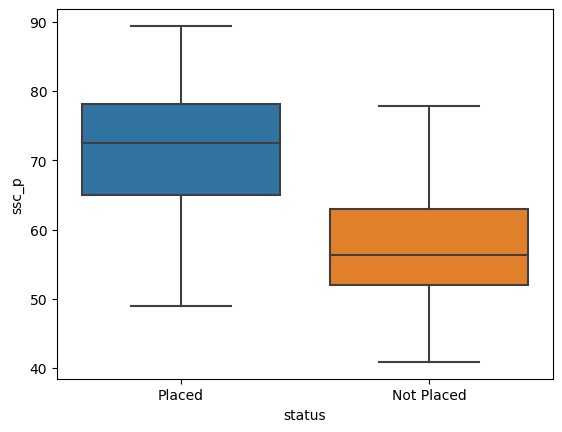

In [15]:
#Simple visualization 
sns.boxplot(x='status', y='ssc_p', data=dataset)
plt.show()

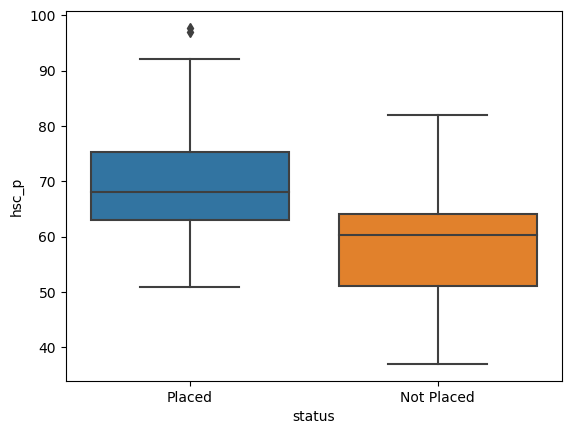

In [16]:
sns.boxplot(x='status', y='hsc_p', data=dataset)
plt.show()

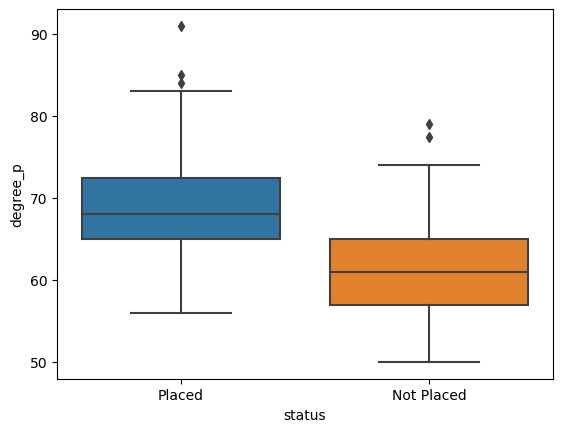

In [17]:
sns.boxplot(x='status', y='degree_p', data=dataset)
plt.show()

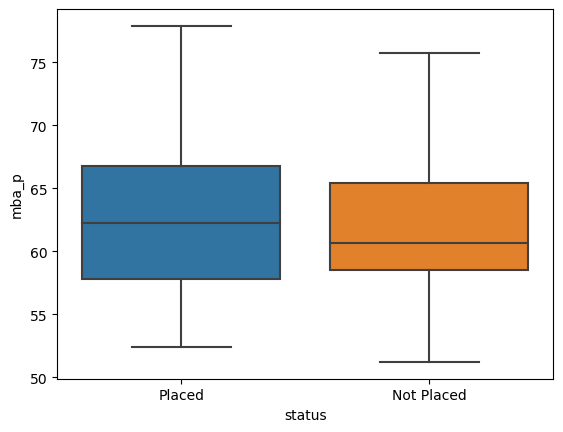

In [18]:
sns.boxplot(x='status', y='mba_p', data=dataset)
plt.show()

# What kind of relation between salary and mba_p

In [19]:
dataset.corr()

,sl_no,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary,status_binary
sl_no,1.000000,-0.078155,-0.085711,-0.088281,0.063636,0.022327,0.002543,-0.026859
ssc_p,-0.078155,1.000000,0.511472,0.538404,0.261993,0.388478,0.538090,0.607889
hsc_p,-0.085711,0.511472,1.000000,0.434206,0.245113,0.354823,0.452569,0.491228
degree_p,-0.088281,0.538404,0.434206,1.000000,0.224470,0.402364,0.408371,0.479861
etest_p,0.063636,0.261993,0.245113,0.224470,1.000000,0.218055,0.186988,0.127639
mba_p,0.022327,0.388478,0.354823,0.402364,0.218055,1.000000,0.139823,0.076922
salary,0.002543,0.538090,0.452569,0.408371,0.186988,0.139823,1.000000,0.865774
status_binary,-0.026859,0.607889,0.491228,0.479861,0.127639,0.076922,0.865774,1.000000


The correlation between salary and mba_p is 0.1398, indicating a weak positive correlation.

Correlation between salary and mba_p: 0.13982273892615565


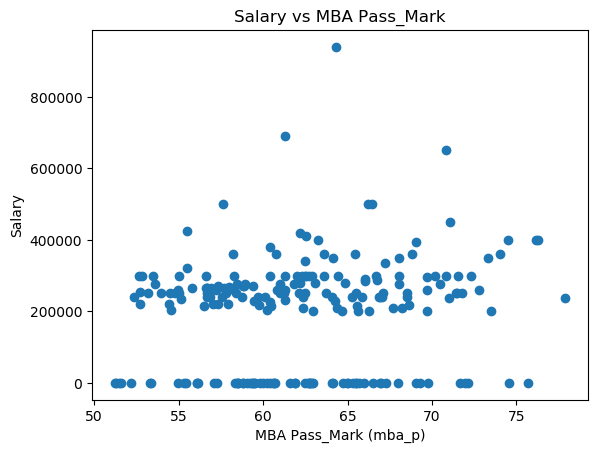

In [20]:
#Correlation
correlation = dataset['salary'].corr(dataset['mba_p'])
print("Correlation between salary and mba_p:", correlation)
#Scatter Plot (Visualization)
plt.scatter(dataset['mba_p'], dataset['salary'])
plt.xlabel("MBA Pass_Mark (mba_p)")
plt.ylabel("Salary")
plt.title("Salary vs MBA Pass_Mark")
plt.show()

# Which specialization is getting minimum salary?

In [21]:
dataset.groupby('specialisation')['salary'].min(axis=1)

specialisation
Mkt&Fin    0.0
Mkt&HR     0.0
Name: salary, dtype: float64

We will get the above output because we have replaced the missing value by zero.

In [22]:
dataset[dataset['salary'] > 0].groupby('specialisation')['salary'].min()

specialisation
Mkt&Fin    200000.0
Mkt&HR     200000.0
Name: salary, dtype: float64

# How many of them getting above 500000 salary?

In [23]:
count = dataset[dataset['salary'] > 500000].shape[0]
print("Number of students with salary above 5,00,000:", count)

Number of students with salary above 5,00,000: 3


# Test the Analysis of Variance between etest_p and mba_p at signifance level 5%.(Make decision using Hypothesis Testing)

In [24]:
f_stat, p_val=stats.f_oneway(dataset['etest_p'],dataset['mba_p'])
print(f"F-statistic: {f_stat:.4f}, P-value: {p_val:.4f}")

# Interpretation

if p_val < 0.05:
    print("Reject Null Hypothesis (H0)")
    print("There is a significant difference between etest_p and mba_p")
else:
    print("Fail to Reject Null Hypothesis (H0)")
    print("No significant difference between etest_p and mba_p")

F-statistic: 98.6449, P-value: 0.0000
Reject Null Hypothesis (H0)
There is a significant difference between etest_p and mba_p


# Test the similarity between the degree_t(Sci&Tech) and specialisation (Mkt&HR) with respect to salary at significance level of 5%.(Makedecision using Hypothesis Testing)

#2different group but same condition (salary)

In [25]:
#unpaired T-test - independent samples
from scipy.stats import ttest_ind

# Split groups
degree = dataset[dataset['degree_t'] == 'Sci&Tech']['salary']
specialisation = dataset[dataset['specialisation'] == 'Mkt&HR']['salary']

# Perform Welch’s t-test
result = ttest_ind(degree, specialisation, equal_var=False)

# Extract and convert to normal float
t_stat = float(result.statistic)
p_val = float(result.pvalue)

# Print clean output
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.4f}")

# Interpretation

if p_val < 0.05:
    print("Reject Null Hypothesis (H0)")
    print("There is a significant difference between degree_t(Sci&Tech) and specialisation (Mkt&HR) with respect to salary")
else:
    print("Fail to Reject Null Hypothesis (H0)")
    print("No significant difference between degree_t(Sci&Tech) and specialisation (Mkt&HR) with respect to salary")

T-statistic: 2.5841
P-value: 0.0111
Reject Null Hypothesis (H0)
There is a significant difference between degree_t(Sci&Tech) and specialisation (Mkt&HR) with respect to salary


# Convert the normal distribution to standard normal distribution for salary column

Mean: 198702.32558139536
Standard Deviation: 154780.92671560097


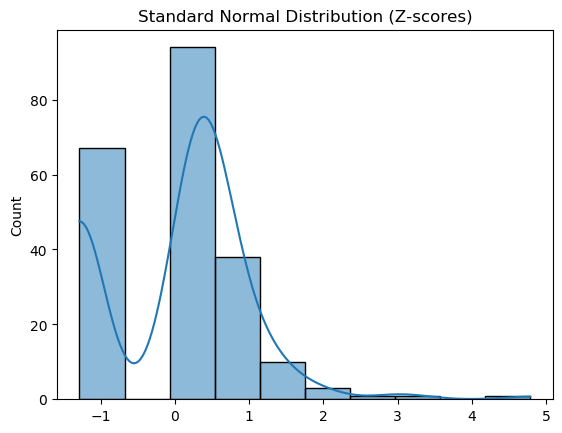

Mean of Z-scores: -7.849018592698781e-17
Std of Z-scores: 0.9976717081331423


In [26]:
# Mean and std
mean = dataset['salary'].mean()
sd = dataset['salary'].std()

print('Mean:', mean)
print('Standard Deviation:', sd)

# Z-score conversion
z_score = [(x - mean) / sd for x in dataset['salary']]

# Plot
sns.histplot(z_score, kde=True)
plt.title("Standard Normal Distribution (Z-scores)")
plt.show()

# Validation
print("Mean of Z-scores:", np.mean(z_score))
print("Std of Z-scores:", np.std(z_score))

# What is the probability Density Function of the salary range from 700000 to 900000?

C:\Anaconda\envs\aids\lib\site-packages\ipykernel_launcher.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  """


Mean=198702.326, Standard Deviation=154780.927
The area between range(700000,900000):0.0005973310593974868


0.0005973310593974868

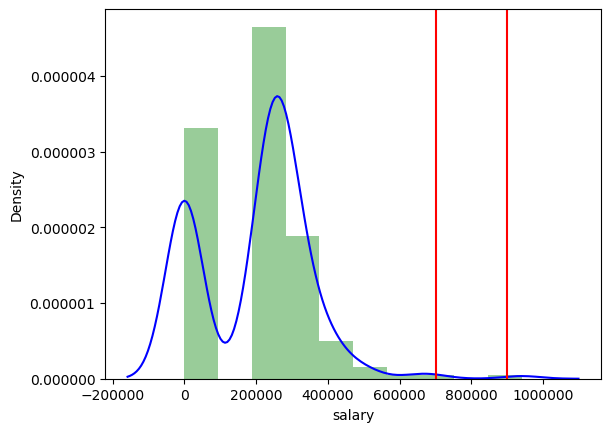

In [27]:
def get_pdf_probability(dataset,startrange,endrange):
    from matplotlib import pyplot
    from scipy.stats import norm
    import seaborn as sns
    ax = sns.distplot(dataset,kde=True,kde_kws={'color':'blue'},color='Green')
    pyplot.axvline(startrange,color='Red')
    pyplot.axvline(endrange,color='Red')
    # generate a sample
    sample = dataset
    # calculate parameters
    sample_mean =sample.mean()
    sample_std = sample.std()
    print('Mean=%.3f, Standard Deviation=%.3f' % (sample_mean, sample_std))
    # define the distribution
    dist = norm(sample_mean, sample_std)
    
    # sample probabilities for a range of outcomes
    values = [value for value in range(startrange, endrange)]
    probabilities = [dist.pdf(value) for value in values]    
    prob=sum(probabilities)
    print("The area between range({},{}):{}".format(startrange,endrange,sum(probabilities)))
    return prob
get_pdf_probability(dataset["salary"],700000,900000)

In [28]:
def get_probability_with_plot(dataset, startrange, endrange):
    import numpy as np
    import matplotlib.pyplot as plt
    from scipy.stats import norm
    import seaborn as sns

    # Plot distribution
    sns.histplot(dataset, kde=True, stat="density", color="green", bins=30)

    # Calculate mean and std
    sample_mean = dataset.mean()
    sample_std = dataset.std()
    print('Mean = %.3f, Standard Deviation = %.3f' % (sample_mean, sample_std))

    # Create normal distribution
    dist = norm(sample_mean, sample_std)

    # Generate x values
    x = np.linspace(min(dataset), max(dataset), 1000)
    y = dist.pdf(x)

    # Plot PDF curve
    plt.plot(x, y, color='blue')

    # Shade area between range
    x_range = np.linspace(startrange, endrange, 1000)
    y_range = dist.pdf(x_range)
    plt.fill_between(x_range, y_range, color='red', alpha=0.5)

    # Draw vertical lines
    plt.axvline(startrange, color='black', linestyle='--')
    plt.axvline(endrange, color='black', linestyle='--')

    # Calculate exact probability using CDF
    probability = dist.cdf(endrange) - dist.cdf(startrange)

    print(f"Probability between {startrange} and {endrange}: {probability}")

    plt.title("Salary Distribution with Highlighted Probability Range")
    plt.xlabel("Salary")
    plt.ylabel("Density")
    plt.show()

    return probability

Mean = 198702.326, Standard Deviation = 154780.927
Probability between 700000 and 900000: 0.0005973243061798694


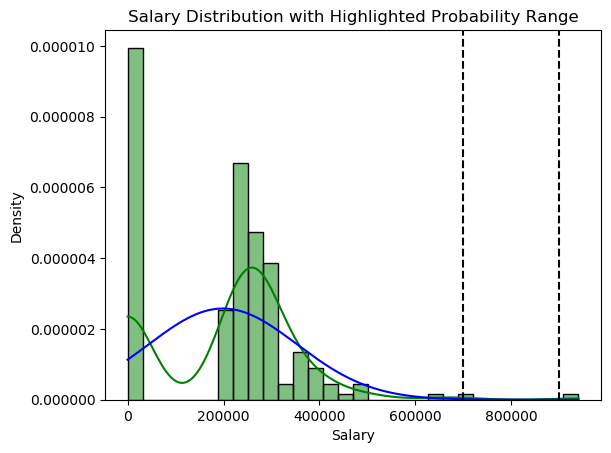

0.0005973243061798694

In [29]:
get_probability_with_plot(dataset["salary"], 700000, 900000)

# Test the similarity between the degree_t(Sci&Tech)with respect to etest_p and mba_p at significance level of 5%.(Make decision using Hypothesis Testing)

In [30]:
# Paired T-test - Dependent sample
d1 = dataset[dataset['degree_t']=='Sci&Tech']['etest_p']
d2 = dataset[dataset['degree_t']=='Sci&Tech']['mba_p']
#print(male)
ttest_ind(d1, d2)

# Extract and convert to normal float
t_stat = float(result.statistic)
p_val = float(result.pvalue)

# Print clean output
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.4f}")

# Interpretation
if p_val < 0.05:
    print("Reject Null Hypothesis (H0)")
    print("There is a significant difference between etest_p and mba_p with respect to degree_t (Sci&Tech)")
else:
    print("Fail to Reject Null Hypothesis (H0)")
    print("No significant difference between etest_p and mba_p with respect to degree_t (Sci&Tech)")

T-statistic: 2.5841
P-value: 0.0111
Reject Null Hypothesis (H0)
There is a significant difference between etest_p and mba_p with respect to degree_t (Sci&Tech)


In [31]:
#Which parameter is highly correlated with salary?
dataset.corr()


,sl_no,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary,status_binary
sl_no,1.000000,-0.078155,-0.085711,-0.088281,0.063636,0.022327,0.002543,-0.026859
ssc_p,-0.078155,1.000000,0.511472,0.538404,0.261993,0.388478,0.538090,0.607889
hsc_p,-0.085711,0.511472,1.000000,0.434206,0.245113,0.354823,0.452569,0.491228
degree_p,-0.088281,0.538404,0.434206,1.000000,0.224470,0.402364,0.408371,0.479861
etest_p,0.063636,0.261993,0.245113,0.224470,1.000000,0.218055,0.186988,0.127639
mba_p,0.022327,0.388478,0.354823,0.402364,0.218055,1.000000,0.139823,0.076922
salary,0.002543,0.538090,0.452569,0.408371,0.186988,0.139823,1.000000,0.865774
status_binary,-0.026859,0.607889,0.491228,0.479861,0.127639,0.076922,0.865774,1.000000


In [32]:
# Compute correlation matrix excluding the status binary
corr_matrix = dataset.drop(columns=['status_binary']).corr()
# Get correlation with salary
salary_corr = corr_matrix['salary'].drop('salary')
# Find highest correlated feature
max_feature = salary_corr.idxmax()
max_value = salary_corr.max()

print("Highest correlated feature (excluding status_binary):", max_feature)
print("Correlation value:", round(max_value, 4))


Highest correlated feature (excluding status_binary): ssc_p
Correlation value: 0.5381


In [ ]:
#plot any useful graph and explain it.

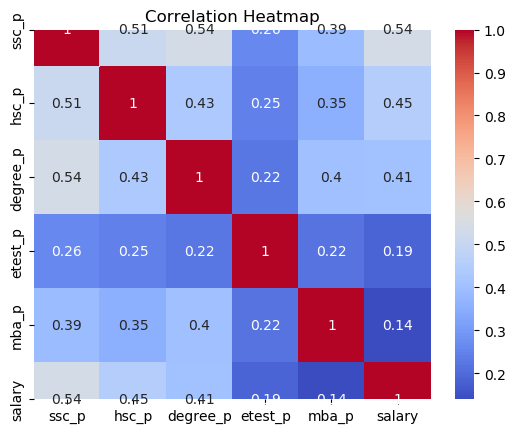

In [33]:
#Correlation Heatmap

# Remove unwanted columns
clean_data = dataset.drop(columns=['sl_no', 'status_binary'])

# Plot heatmap
sns.heatmap(clean_data.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


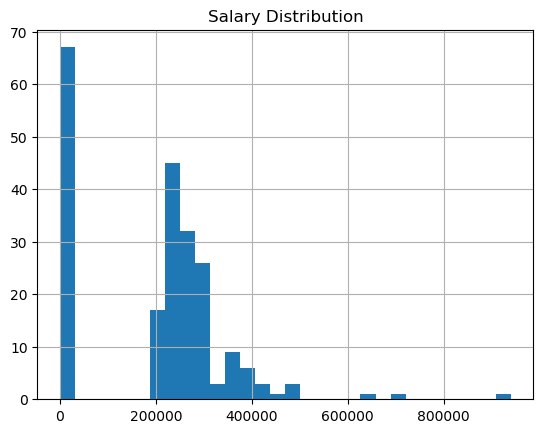

In [34]:
#Histogram
dataset['salary'].hist(bins=30)
plt.title("Salary Distribution")
plt.show()

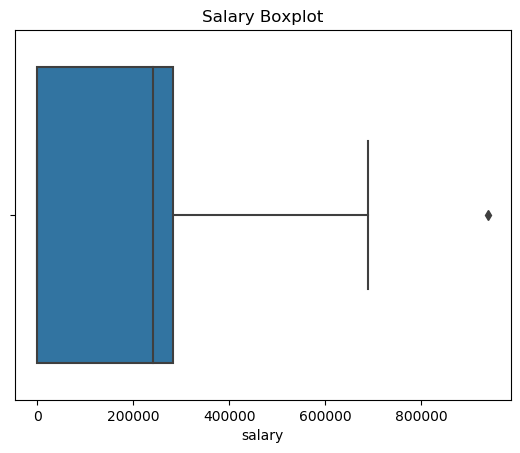

In [35]:
#Box Plot
sns.boxplot(x=dataset['salary'])
plt.title("Salary Boxplot")
plt.show()

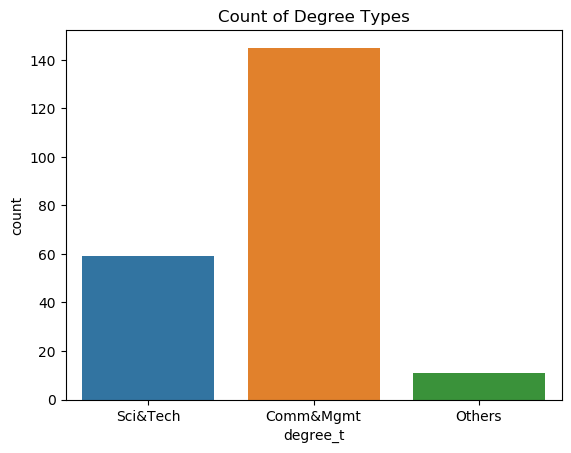

In [36]:
#Count Plot
sns.countplot(x='degree_t', data=dataset)
plt.title("Count of Degree Types")
plt.show()

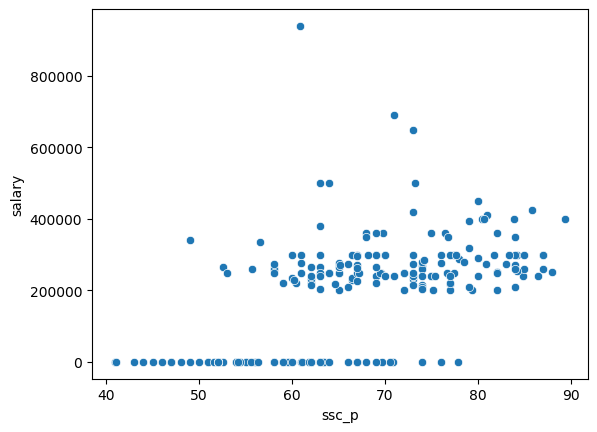

In [37]:
#Scatter Plot (Relationship with Salary)
sns.scatterplot(x='ssc_p', y='salary', data=dataset)
plt.show()

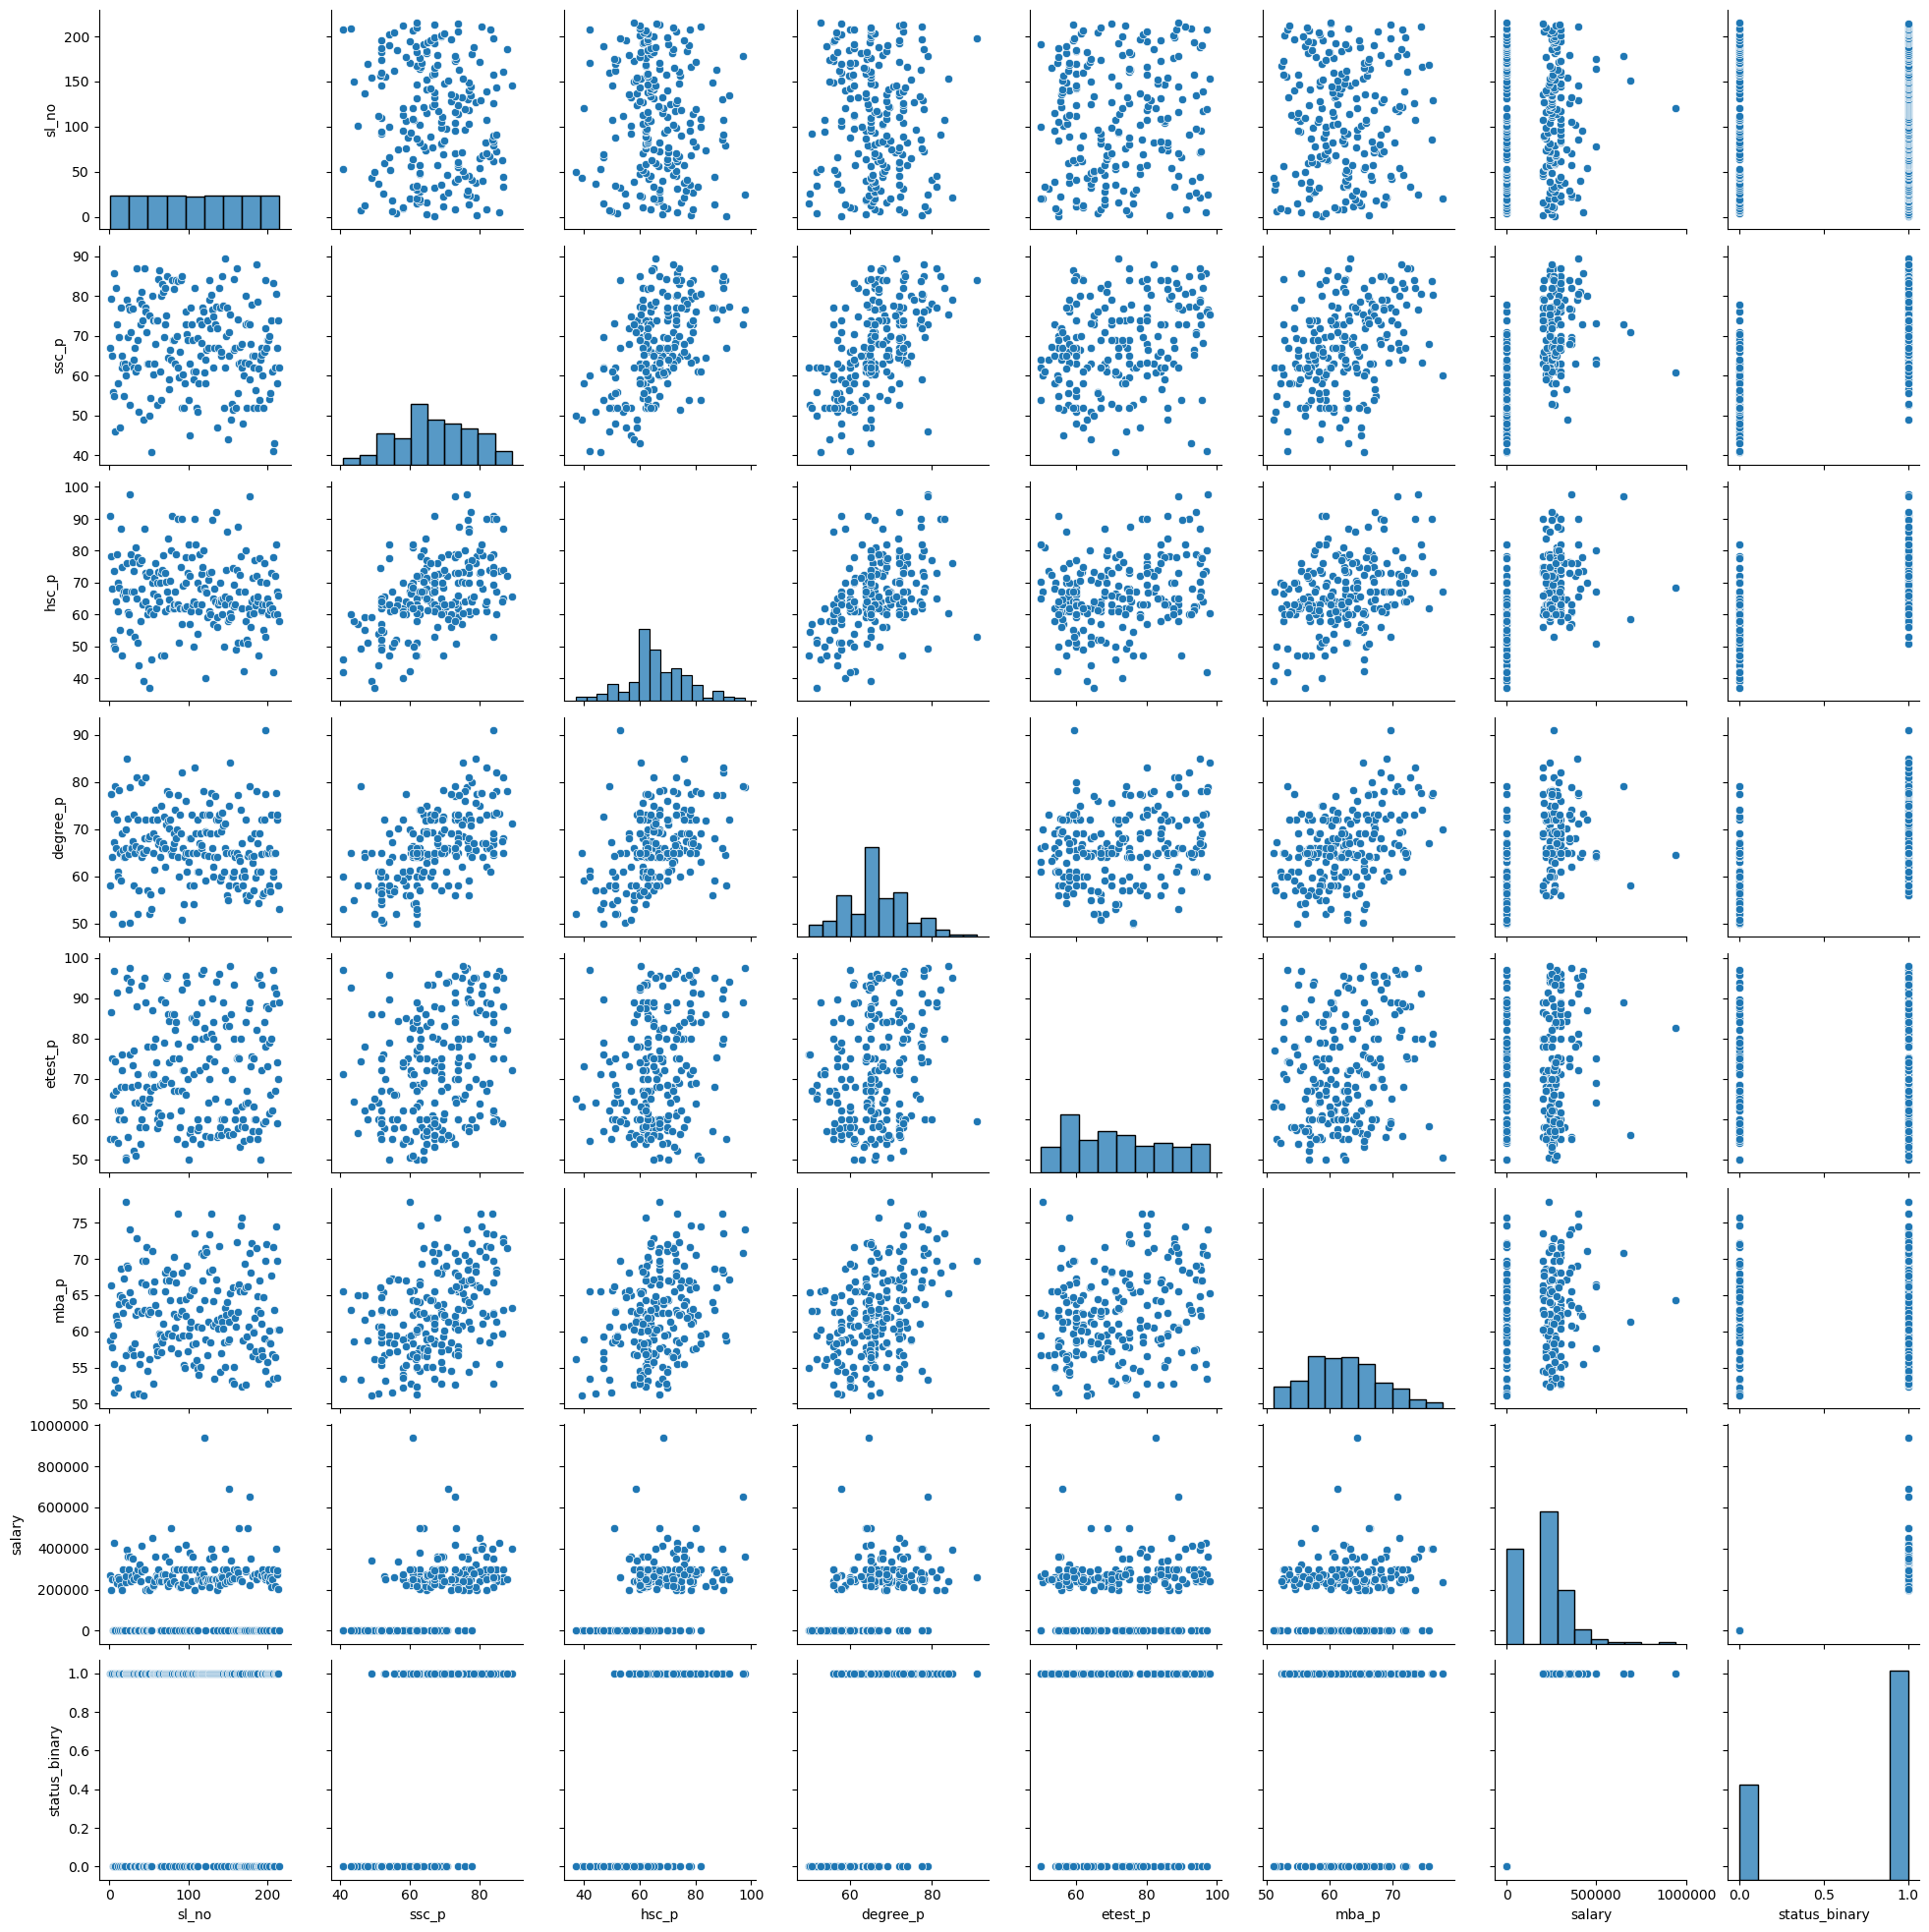

In [38]:
#Pair Plot (All Relationships)
sns.pairplot(dataset)
plt.show()

C:\Anaconda\envs\aids\lib\site-packages\ipykernel_launcher.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  


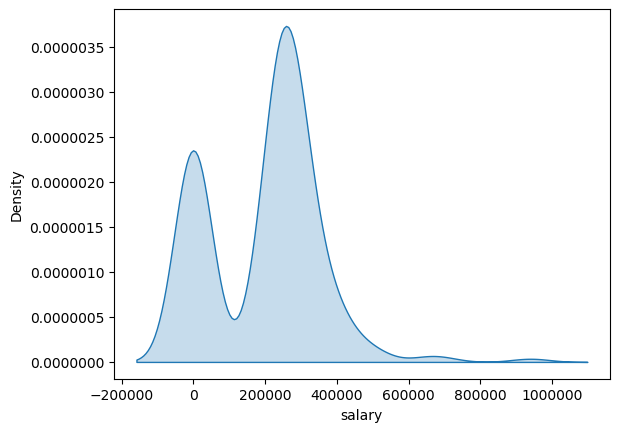

In [39]:
#KDE Plot (Smooth Distribution)
sns.kdeplot(dataset['salary'], shade=True)
plt.show()